# Bangladesh: Inflation and Banking, 2010-2025
**Question:** what trends and associations show up between inflation, the taka and banking indicators?

**Scope:** 16 yearly points. This is exploratory work. It shows associations, not cause.

In [1]:
import sys; sys.path.insert(0, '../src')
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import bdlib as b
sns.set_theme(style='whitegrid', palette='deep'); pd.set_option('display.width', 200)
raw = b.load_raw(); df = b.load_clean(); audit = b.audit_report()
print(raw.shape, '->', df.shape)

(16, 33) -> (16, 27)


## 1. Data audit
The file is called 'Audited', so first I checked whether it deserves the name.

In [2]:
print('Fully empty columns:', len(audit['empty_cols']), 'of', audit['cols'])
for c in audit['empty_cols']: print('  -', c)
print('\nPartly missing:', audit['missing'])
print('Largest gap between given M2 growth and growth recomputed from M2 levels: %.1f pts' % audit['m2_mismatch_max'])

Fully empty columns: 12 of 33
  - Deposit_Rate_%
  - Domestic_Credit_Banking_percent_GDP
  - Real_Deposit_Rate_Approx_%
  - Interest_Rate_Spread_%
  - Housing_Water_Electricity_Gas_Fuels_CPI_Index_Raw
  - Food_NonAlcoholic_Beverages_Inflation_%
  - Producer_Price_Inflation_%
  - Natural_Gas_Production_m3_million
  - Electricity_Generation_kWh_million
  - Housing_Energy_CPI_Annual_Change_%
  - Energy_Output_Growth_%
  - Gas_Output_Growth_%

Partly missing: {'Food_Inflation_Annual_%': 2, 'NPL_percent_Total_Gross_Loans': 2, 'Total_Deposit_Growth_%': 1, 'Private_Sector_Credit_Growth_%': 1, 'Exchange_Rate_Depreciation_%': 1}
Largest gap between given M2 growth and growth recomputed from M2 levels: 3.7 pts


**Decisions**
- Deposit rate is empty, so the planned 'real deposit return' cannot be built. Substitute: **real lending rate** (lending rate minus inflation) and **real deposit growth** (deposit growth minus inflation).
- Housing/energy CPI and producer prices are empty. The household-cost part uses food inflation only.
- M2 growth is recomputed from M2 levels because the given column does not match them.
- Missing values stay blank. No zero-filling.
- NPL 2011 (1.9%) looks wrong next to 2012 (6.7%). Kept, but flagged.

## 2. Inflation trend

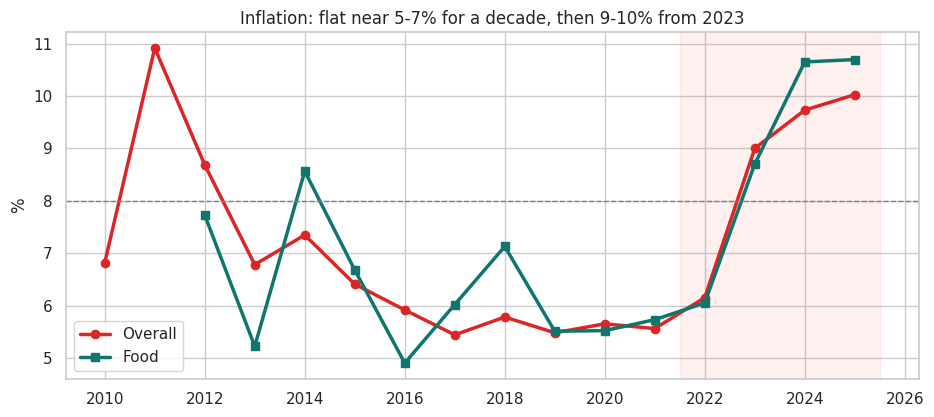

 Year   cpi
 2011 10.92
 2025 10.03
 2024  9.73
 2023  9.00
 2012  8.69


In [3]:
fig, ax = plt.subplots(figsize=(11,4.5))
ax.plot(df.Year, df.cpi, 'o-', lw=2.5, color='#DC2626', label='Overall'); ax.plot(df.Year, df.food, 's-', lw=2.5, color='#0F766E', label='Food')
ax.axvspan(2021.5, 2025.5, color='red', alpha=.06); ax.axhline(8, ls='--', c='grey', lw=1)
ax.set(title='Inflation: flat near 5-7% for a decade, then 9-10% from 2023', ylabel='%'); ax.legend(); plt.show()
f = b.key_findings(df); print(f['top5'].round(2).to_string(index=False))

## 3. Food vs overall inflation

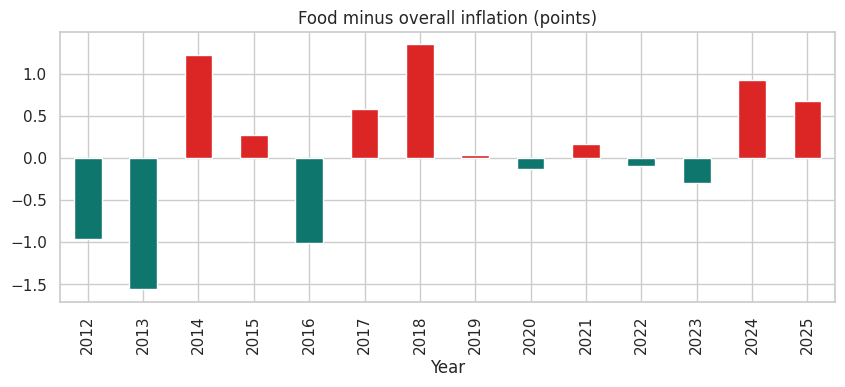

Food above overall in 8 of 14 years: [2014, 2015, 2017, 2018, 2019, 2021, 2024, 2025]


In [4]:
g = df.dropna(subset=['food_gap'])
ax = g.set_index('Year').food_gap.plot.bar(color=np.where(g.food_gap>0,'#DC2626','#0F766E'), figsize=(10,3.5), title='Food minus overall inflation (points)'); plt.show()
print('Food above overall in', (g.food_gap>0).sum(), 'of', len(g), 'years:', f['food_above'])

## 4. Real returns
Inflation eats returns. With no deposit rate, look at lending rate and deposit growth after inflation.

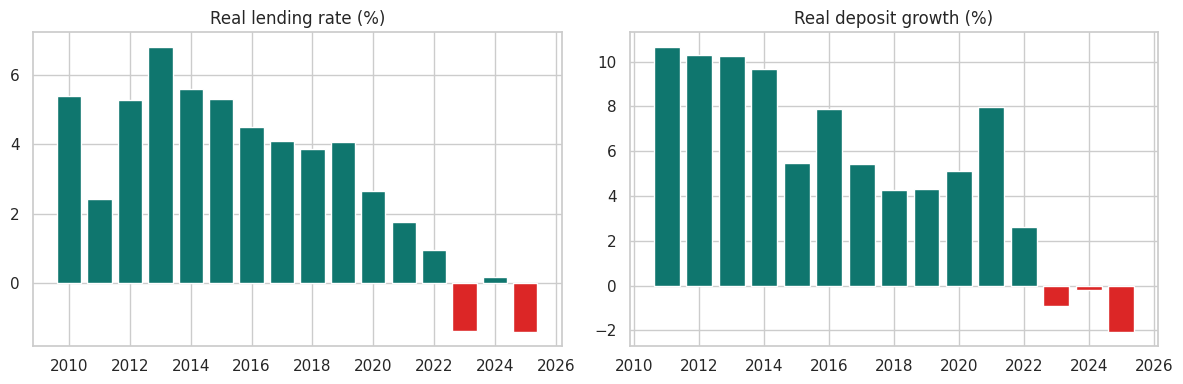

Negative real lending rate: [2023, 2025]
Deposits grew slower than prices: [2023, 2024, 2025]


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].bar(df.Year, df.real_lending_rate, color=np.where(df.real_lending_rate<0,'#DC2626','#0F766E')); ax[0].set_title('Real lending rate (%)')
ax[1].bar(df.Year, df.real_deposit_growth, color=np.where(df.real_deposit_growth<0,'#DC2626','#0F766E')); ax[1].set_title('Real deposit growth (%)')
plt.tight_layout(); plt.show()
print('Negative real lending rate:', f['neg_real_lending']); print('Deposits grew slower than prices:', f['neg_real_deposit'])

## 5. Two eras beat the 'high inflation flag'
The source flag puts 2011, 2012, 2023, 2024, 2025 together. Look at NPL with and without 2024:

In [6]:
hi = df.cpi >= 8
print('NPL, high-inflation years   : all = %.2f | without 2024 = %.2f' % (df.npl[hi].mean(), df.npl[hi & (df.Year!=2024)].mean()))
print('NPL, other years            : %.2f' % df.npl[~hi].mean())
cols = ['cpi','food','npl','credit_growth','deposit_growth','m2_growth','depreciation','real_lending_rate','loan_to_deposit']
df.groupby('period')[cols].mean().T.round(2)

NPL, high-inflation years   : all = 9.29 | without 2024 = 6.07
NPL, other years            : 8.36


period,2010-2021 (stable),2022-2025 (pressure)
cpi,6.73,8.73
food,6.30,9.02
npl,7.59,12.42
credit_growth,14.91,9.42
deposit_growth,14.12,8.59
m2_growth,14.68,7.30
depreciation,1.90,9.48
real_lending_rate,4.31,-0.42
loan_to_deposit,91.37,97.64


**Reading:** the 'high inflation years have more bad loans' story comes almost only from 2024. Without it the gap reverses. The 2010-2021 vs 2022-2025 split is a cleaner comparison.

## 6. Relationships with inflation, with honest uncertainty
With ~15 points, one correlation number is not enough. For each pair I add a bootstrap 95% range and the range when any single year is dropped.

In [7]:
ct = b.corr_table(df).round(2); ct

,indicator,n,pearson,p_value,spearman,ci_low,ci_high,loo_min,loo_max
0,npl,14,0.01,0.96,-0.07,-0.88,0.80,-0.63,0.51
1,deposit_growth,15,0.25,0.36,0.04,-0.46,0.82,-0.09,0.43
2,credit_growth,15,0.13,0.63,0.08,-0.64,0.75,-0.29,0.35
3,depreciation,15,0.59,0.02,0.45,0.32,0.81,0.55,0.64
4,m2_growth,15,-0.18,0.53,-0.03,-0.76,0.63,-0.52,0.00
5,lending_rate,16,0.28,0.29,0.40,-0.20,0.71,0.12,0.40
6,loan_to_deposit,16,-0.04,0.88,-0.23,-0.44,0.41,-0.15,0.06


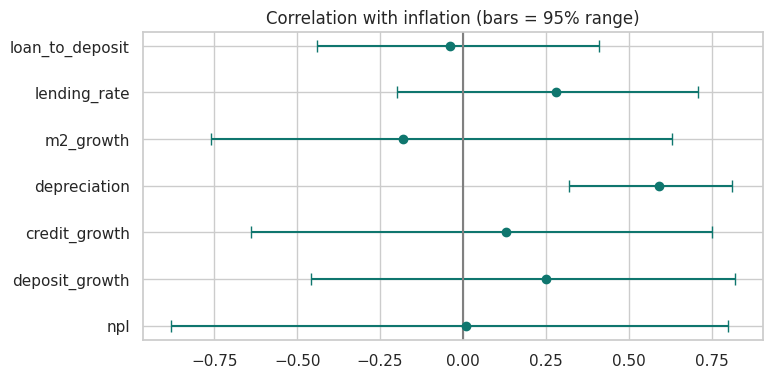

In [8]:
ct2 = ct.set_index('indicator')
fig, ax = plt.subplots(figsize=(8,4))
ax.errorbar(ct2.pearson, range(len(ct2)), xerr=[ct2.pearson-ct2.ci_low, ct2.ci_high-ct2.pearson], fmt='o', color='#0F766E', capsize=4)
ax.axvline(0, c='grey'); ax.set_yticks(range(len(ct2))); ax.set_yticklabels(ct2.index); ax.set(title='Correlation with inflation (bars = 95% range)'); plt.show()

**Reading**
- Only **taka depreciation** has a range fully above zero, and it holds when any single year is dropped (+0.55 to +0.64).
- **NPL, credit growth, deposit growth, M2 growth, credit-to-deposit**: ranges cross zero. No reliable link.
- Caution: 2022-2024 are consecutive years and move together, so real evidence is thinner than the p-value suggests.

## 7. Timing: does depreciation or money growth lead inflation?

In [9]:
for name in ['depreciation','m2_growth']:
    print(name, {lag: round(pd.DataFrame({'x':df[name].shift(lag),'y':df.cpi}).dropna().corr().iloc[0,1],2) for lag in [0,1,2]})

depreciation {0: np.float64(0.59), 1: np.float64(0.69), 2: np.float64(0.64)}
m2_growth {0: np.float64(-0.18), 1: np.float64(-0.48), 2: np.float64(-0.53)}


Depreciation keeps a positive link at a 1-year and 2-year lead (+0.69, +0.64). M2 growth turns *negative* at longer leads (-0.48, -0.53): money growth slowed while inflation rose in 2023-25, so 'too much money' does not explain these years. With about 14 points this is a lead to test, not a result. Note: the M2 growth column given in the source file (not recomputed) gives a different, weakly positive result (+0.21 at lag 1), so the answer depends on which M2 series is correct. That is another reason to verify the source.

## 8. Correlation heatmap

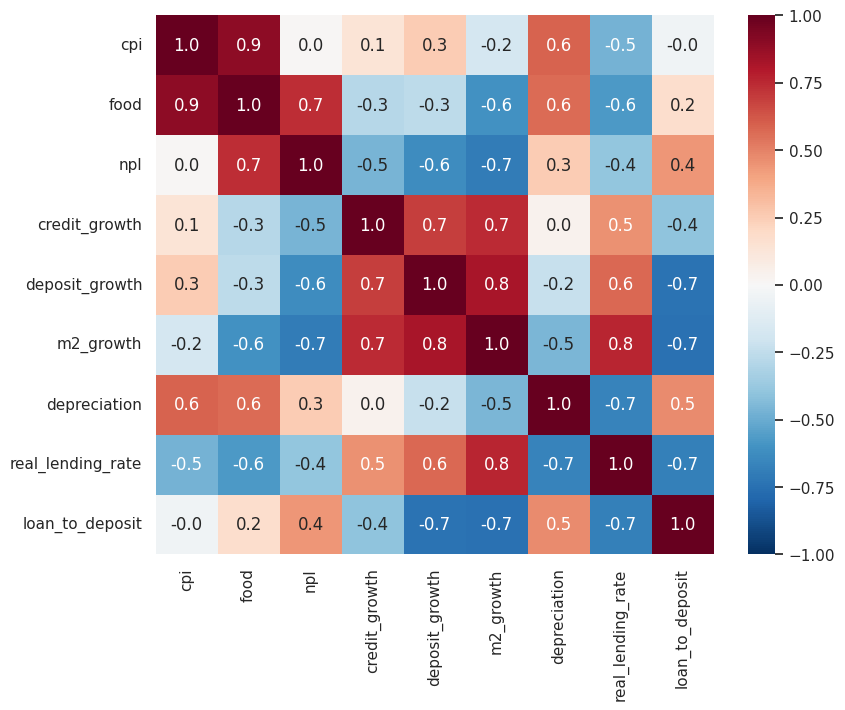

In [10]:
plt.figure(figsize=(9,7)); sns.heatmap(df[cols].corr(), annot=True, fmt='.1f', cmap='RdBu_r', center=0, vmin=-1, vmax=1); plt.show()

## 9. Conclusions
1. Inflation was 5-7% for 2013-2022, spiked in 2011 (10.9%) and again from 2023 (9.0% to 10.0% in 2025).
2. Food inflation is not always worse than overall inflation: above in 8 of 14 years, worse in 2024-25.
3. Real lending rates fell below zero in 2023 and 2025. Deposits grew slower than prices in 2023-2025.
4. 2022-2025 vs 2010-2021: credit growth 14.9% to 9.4%, deposit growth 14.1% to 8.6%, NPL 7.6% to 12.4%, taka fall 1.9% to 9.5% a year.
5. The only relationship that holds up is inflation with taka depreciation.
6. Not proven: that inflation hurts banks. NPL and credit show no reliable link in this sample.

**Limits:** 16 points, 12 empty columns, two suspicious NPL values, no deposit rate, no cause-and-effect test.

**Next step:** get deposit rate, housing CPI and PPI from Bangladesh Bank and BBS, and move to monthly data (about 190 points).